# Generative Machine Learning Approaches to Optimization

This notebook contains all code examples from the manuscript, organized by section.

**Authors:** Victor Alves and John R. Kitchin

## Table of Contents

1. [Utility Functions](#utilities)
2. [Root Finding](#root-finding)
   - [Real Roots](#real-roots)
   - [Newton-Raphson Inspired](#newton-raphson)
   - [Imaginary Roots](#imaginary-roots)
3. [Optimization with Generative Models](#optimization)
4. [Constrained Optimization](#constrained)
   - [Equality Constraints](#equality)
   - [Inequality Constraints](#inequality)
5. [Parameter Estimation](#parameter-estimation)
6. [Mapping Input and Output Spaces](#mapping)

---
<a id='utilities'></a>
## 1. Utility Functions

These utility functions provide consistent sampling, GMM selection, and analysis throughout all examples.

### 1.1 Imports and Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# Configure JAX to use CPU (avoids GPU/XLA compatibility issues)
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from scipy.stats.qmc import Sobol, LatinHypercube, scale
from gmr import GMM

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

### 1.2 Sampling Utilities

In [2]:
def generate_samples(bounds, n_samples=None, method='sobol', seed=42):
    """
    Generate samples in a bounded region with consistent strategy.
    
    Parameters
    ----------
    bounds : array-like, shape (n_dims, 2)
        [[low1, high1], [low2, high2], ...]
    n_samples : int, optional
        Number of samples. Default: 2^ceil(log2(20 * n_dims))
    method : str
        'sobol', 'latin', or 'uniform'
    seed : int
        Random seed
        
    Returns
    -------
    samples : ndarray, shape (n_samples, n_dims)
    """
    bounds = np.atleast_2d(bounds)
    n_dims = len(bounds)
    
    if n_samples is None:
        # Heuristic: exponential in dimension, but reasonable
        n_samples = 2 ** int(np.ceil(np.log2(20 * n_dims)))
        n_samples = min(n_samples, 4096)
    
    lower = bounds[:, 0]
    upper = bounds[:, 1]
    
    if method == 'sobol':
        sampler = Sobol(d=n_dims, scramble=True, seed=seed)
        # Sobol works best with power of 2
        n_samples = 2 ** int(np.ceil(np.log2(n_samples)))
        raw = sampler.random(n=n_samples)
    elif method == 'latin':
        sampler = LatinHypercube(d=n_dims, seed=seed)
        raw = sampler.random(n=n_samples)
    else:  # uniform
        rng = np.random.default_rng(seed)
        raw = rng.uniform(0, 1, (n_samples, n_dims))
    
    return scale(raw, lower, upper)


def estimate_sample_size(n_dims, n_components_expected=5, samples_per_param=20):
    """
    Estimate required sample size for GMM fitting.
    
    A GMM with k components in d dimensions has approximately:
    k * (1 + d + d(d+1)/2) parameters
    
    Parameters
    ----------
    n_dims : int
        Number of dimensions in the data
    n_components_expected : int
        Expected number of GMM components
    samples_per_param : int
        Samples per parameter (rule of thumb: 10-30)
        
    Returns
    -------
    n_samples : int
        Recommended sample size (power of 2 for Sobol)
    """
    n_params_per_component = 1 + n_dims + n_dims * (n_dims + 1) // 2
    total_params = n_components_expected * n_params_per_component
    n_samples = samples_per_param * total_params
    
    # Round up to power of 2 for Sobol
    n_samples = 2 ** int(np.ceil(np.log2(n_samples)))
    
    return min(n_samples, 8192)

### 1.3 GMM Selection with Early Stopping

In [3]:
def best_gmm(X, max_components=None, criterion='bic', 
             reg_covar=1e-6, n_init=3, patience=10,
             verbose=False):
    """
    Find the best GMM using information criteria with early stopping.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Training data
    max_components : int, optional
        Maximum components to try. Default: min(50, n_samples // (5 * n_features))
    criterion : str
        'bic' or 'aic' for model selection
    reg_covar : float
        Regularization for covariance matrices (prevents singularity)
    n_init : int
        Number of initializations per component count
    patience : int
        Stop if no improvement for this many components
    verbose : bool
        Print progress
        
    Returns
    -------
    gmm : GMM
        Best model from gmr library
    info : dict
        Dictionary with 'scores', 'best_k', 'all_models'
    """
    X = np.atleast_2d(X)
    n_samples, n_features = X.shape
    
    if max_components is None:
        max_components = min(50, max(2, n_samples // (5 * n_features)))
    
    scores = []
    models = []
    best_score = np.inf
    best_k = 1
    no_improvement = 0
    
    for k in range(1, max_components + 1):
        try:
            model = GaussianMixture(
                n_components=k,
                covariance_type='full',
                reg_covar=reg_covar,
                n_init=n_init,
                random_state=42
            ).fit(X)
            
            score = model.bic(X) if criterion == 'bic' else model.aic(X)
            
        except Exception as e:
            if verbose:
                print(f"k={k}: Failed - {e}")
            continue
            
        scores.append(score)
        
        gmm = GMM(
            n_components=model.n_components,
            priors=model.weights_,
            means=model.means_,
            covariances=model.covariances_
        )
        models.append(gmm)
        
        if score < best_score:
            best_score = score
            best_k = len(models)  # index in models list
            no_improvement = 0
        else:
            no_improvement += 1
            
        if verbose:
            marker = " *" if no_improvement == 0 else ""
            print(f"k={k}: {criterion.upper()}={score:.1f}{marker}")
            
        if no_improvement >= patience:
            if verbose:
                print(f"Early stopping at k={k}")
            break
    
    info = {
        'scores': scores,
        'best_k': best_k,
        'all_models': models,
        'criterion': criterion
    }
    
    return models[best_k - 1], info


# Backwards-compatible wrapper matching original API
def best_gmm_bic(X, maxN=None):
    """Legacy wrapper for best_gmm with BIC criterion."""
    gmm, info = best_gmm(X, max_components=maxN, criterion='bic')
    # Attach extra attributes for compatibility
    gmm.models = info['all_models']
    gmm.bics = info['scores']
    return gmm

### 1.4 Cluster Analysis

In [4]:
def cluster_stats(X, eps=0.5, min_samples=5, return_stats=False):
    """
    Compute mean and stdev for clusters in sampled data.
    
    Parameters
    ----------
    X : array-like, shape (n_samples,) or (n_samples, n_features)
        Data to cluster
    eps : float
        DBSCAN neighborhood radius
    min_samples : int
        Minimum samples for core point
    return_stats : bool
        If True, return dictionary of statistics
        
    Returns
    -------
    stats : dict (if return_stats=True)
        {label: {'mean': ..., 'std': ..., 'n': ...}}
    """
    X = np.atleast_2d(X)
    if X.shape[0] == 1:
        X = X.T
    
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = clustering.labels_
    
    stats = {}
    for L in sorted(set(labels)):
        mask = labels == L
        cluster_data = X[mask]
        
        if X.shape[1] == 1:
            mean = np.mean(cluster_data)
            std = np.std(cluster_data)
            print(f'{L:3d}: {mean: 8.4f} +/- {std:.4f} (n={np.sum(mask)})')
        else:
            mean = np.mean(cluster_data, axis=0)
            std = np.std(cluster_data, axis=0)
            print(f'{L:3d}: mean={mean}, std={std} (n={np.sum(mask)})')
            
        stats[L] = {'mean': mean, 'std': std, 'n': np.sum(mask)}
    
    if return_stats:
        return stats

### 1.5 Validation Utilities

In [5]:
def validate_gmm(gmm, X, input_cols, output_cols=None, plot=True):
    """
    Validate GMM fit with parity plot and metrics.
    
    Parameters
    ----------
    gmm : GMM
        Fitted model
    X : ndarray
        Data used for fitting
    input_cols : list of int
        Column indices to condition on
    output_cols : list of int, optional
        Column indices to predict. Default: all columns not in input_cols
    plot : bool
        Whether to show parity plot
        
    Returns
    -------
    metrics : dict
        R2, MAE, RMSE for each output column
    """
    if output_cols is None:
        output_cols = [i for i in range(X.shape[1]) if i not in input_cols]
    
    inputs = X[:, input_cols]
    true_outputs = X[:, output_cols]
    pred_outputs = gmm.predict(input_cols, inputs)
    
    metrics = {}
    
    if plot:
        n_outputs = len(output_cols)
        fig, axes = plt.subplots(1, n_outputs, figsize=(4*n_outputs, 4))
        if n_outputs == 1:
            axes = [axes]
    
    for i, col in enumerate(output_cols):
        true = true_outputs[:, i]
        pred = pred_outputs[:, i]
        
        ss_res = np.sum((true - pred) ** 2)
        ss_tot = np.sum((true - np.mean(true)) ** 2)
        
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        mae = np.mean(np.abs(true - pred))
        rmse = np.sqrt(np.mean((true - pred) ** 2))
        
        metrics[f'col_{col}'] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
        
        if plot:
            ax = axes[i]
            ax.scatter(true, pred, alpha=0.5, s=10)
            lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
            ax.plot(lims, lims, 'k--', lw=1)
            ax.set_xlabel(f'True (col {col})')
            ax.set_ylabel(f'Predicted (col {col})')
            ax.set_title(f'R² = {r2:.4f}')
            ax.set_aspect('equal')
    
    if plot:
        plt.tight_layout()
        plt.show()
    
    return metrics

---
<a id='root-finding'></a>
## 2. Root Finding

In root finding we seek to find the values of $x$ where $f(x)=0$.

<a id='real-roots'></a>
### 2.1 Real Roots

We demonstrate root finding on a polynomial $y = x^4 - 4x^2 + x + 3$ which has two real roots.

In [6]:
# Define the function and find analytical roots
x = np.linspace(-2.25, 2, 200)
y = x**4 - 4*x**2 + x + 3

# Analytical roots using numpy
roots = np.roots([1, 0, -4, 1, 3])
print("All roots (including complex):")
print(roots)
print(f"\nReal roots: {roots[roots.imag == 0].real}")

All roots (including complex):
[ 1.36778435+0.23154129j  1.36778435-0.23154129j -1.92630322+0.j
 -0.80926547+0.j        ]

Real roots: [-1.92630322 -0.80926547]


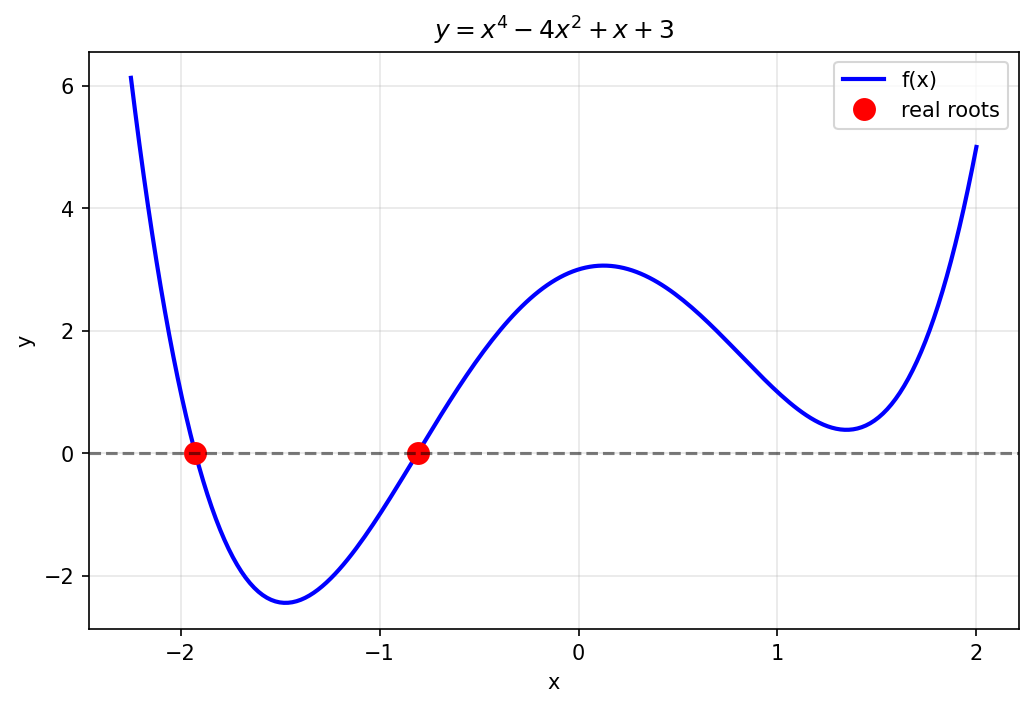

In [7]:
# Visualize the function and roots
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', lw=2, label='f(x)')
plt.plot([-1.92630322, -0.80926547], [0, 0], 'ro', ms=10, label='real roots')
plt.axhline(0, color='k', ls='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('$y = x^4 - 4x^2 + x + 3$')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Build generative model for root finding
data = np.array([x, y]).T

gmm, info = best_gmm(data, verbose=True)
print(f"\nBest model: {info['best_k']} components")

k=1: BIC=1468.6 *
k=2: BIC=1346.6 *
k=3: BIC=1190.7 *
k=4: BIC=992.9 *
k=5: BIC=780.4 *
k=6: BIC=664.2 *
k=7: BIC=523.8 *
k=8: BIC=504.1 *
k=9: BIC=439.7 *
k=10: BIC=430.2 *
k=11: BIC=317.6 *
k=12: BIC=343.7
k=13: BIC=298.9 *
k=14: BIC=253.9 *
k=15: BIC=257.5
k=16: BIC=254.5
k=17: BIC=231.6 *
k=18: BIC=222.1 *
k=19: BIC=194.2 *
k=20: BIC=220.5

Best model: 19 components


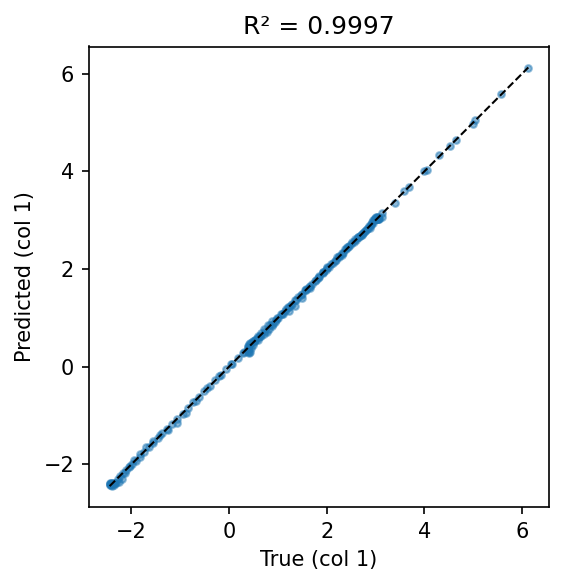


R² = 0.9997
MAE = 0.0233


In [9]:
# Validate the model fit
metrics = validate_gmm(gmm, data, input_cols=[0], output_cols=[1])
print(f"\nR² = {metrics['col_1']['R2']:.4f}")
print(f"MAE = {metrics['col_1']['MAE']:.4f}")

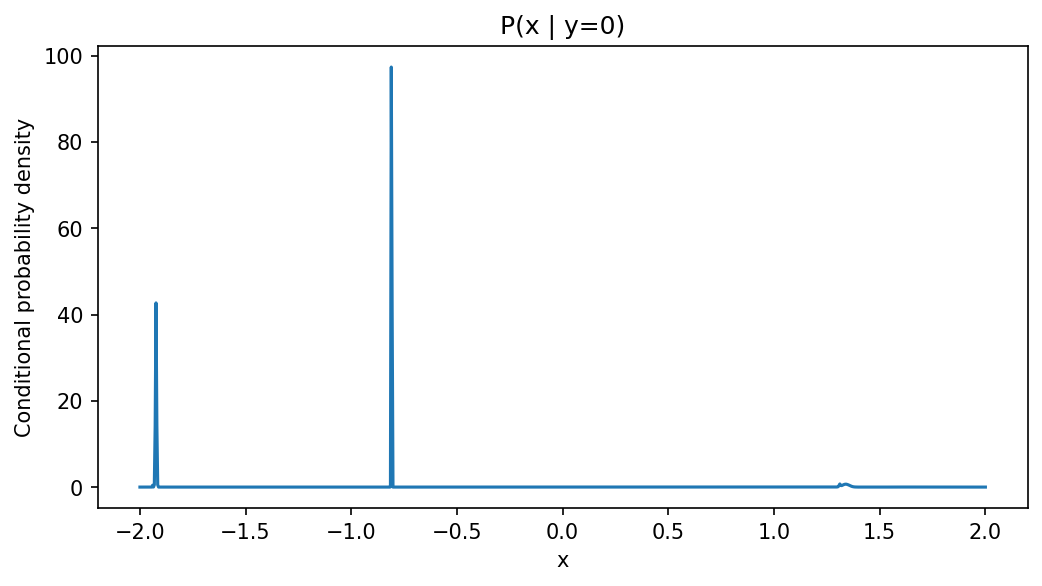

In [10]:
# Compute conditional probability density for y=0
c = gmm.condition([1], [[0.0]])  # condition on y=0

_x = np.linspace(-2, 2, 1000)[:, None]

plt.figure(figsize=(8, 4))
plt.plot(_x, c.to_probability_density(_x))
plt.xlabel('x')
plt.ylabel('Conditional probability density')
plt.title('P(x | y=0)')
plt.show()

In [11]:
# Sample the conditional distribution to find roots
print("Roots found by sampling (y=0):")
cluster_stats(c.sample(1000))

Roots found by sampling (y=0):
  0:   1.3375 +/- 0.0460 (n=39)
  1:  -1.9238 +/- 0.0029 (n=313)
  2:  -0.8092 +/- 0.0013 (n=648)


In [12]:
# Verify the samples - check which ones are actually roots
# The cluster near x≈1.35 is a GMM artifact (the function has a local min there ≈ 0.38, not 0)

samples = c.sample(1000)
f_at_samples = samples[:, 0]**4 - 4*samples[:, 0]**2 + samples[:, 0] + 3

print("Verification: f(x) at sampled 'roots':")
print(f"  Mean |f(x)|: {np.mean(np.abs(f_at_samples)):.4f}")
print(f"  Max |f(x)|:  {np.max(np.abs(f_at_samples)):.4f}")

# Filter to actual roots (|f(x)| < tolerance)
tol = 0.1
valid_roots = samples[np.abs(f_at_samples) < tol, 0]
print(f"\nAfter filtering (|f(x)| < {tol}): {len(valid_roots)} samples")
print("Valid root clusters:")
cluster_stats(valid_roots)

print("\nNote: The cluster near x≈1.35 is a GMM artifact - the function")
print("has a local minimum there (f(x)≈0.38), not an actual root.")

Verification: f(x) at sampled 'roots':
  Mean |f(x)|: 0.0246
  Max |f(x)|:  0.3912

After filtering (|f(x)| < 0.1): 967 samples
Valid root clusters:
  0:  -1.9239 +/- 0.0025 (n=278)
  1:  -0.8092 +/- 0.0013 (n=689)

Note: The cluster near x≈1.35 is a GMM artifact - the function
has a local minimum there (f(x)≈0.38), not an actual root.


In [13]:
# We can also condition on other values, e.g., y=5
c = gmm.condition([1], [[5.0]])
print("Values of x where y=5:")
cluster_stats(c.sample(1000))

Values of x where y=5:
  0:   2.0020 +/- 0.0018 (n=374)
  1:  -2.2052 +/- 0.0012 (n=626)


In [14]:
# The GMM can also work in the forward direction
# Given x, predict y
pred_y = gmm.predict([0], [[2.0], [-2.206]])
print("Forward prediction:")
print(f"  x=2.0   -> y={pred_y[0, 0]:.4f} (expected: ~5)")
print(f"  x=-2.206 -> y={pred_y[1, 0]:.4f} (expected: ~5)")

Forward prediction:
  x=2.0   -> y=4.9679 (expected: ~5)
  x=-2.206 -> y=5.0213 (expected: ~5)


### 2.3 Newton-Raphson Inspired Root Finding

Instead of conditioning directly on $f(x) = 0$, we can condition on the Newton-Raphson update step:

$$\frac{f(x)}{f'(x)} = 0$$

When this ratio equals zero, we have $f(x) = 0$ (assuming $f'(x) \neq 0$). This is interesting because:
1. It incorporates derivative information into the root-finding process
2. Near roots, the ratio approaches zero more smoothly than $f(x)$ alone
3. It naturally avoids regions where the derivative is small (potential numerical issues in Newton-Raphson)

In [15]:
# Newton-Raphson inspired: condition on f(x)/f'(x) = 0
# Using the same polynomial: y = x^4 - 4x^2 + x + 3

x = np.linspace(-2.25, 2, 300)
y = x**4 - 4*x**2 + x + 3
y_prime = 4*x**3 - 8*x + 1

# The Newton-Raphson step: f(x)/f'(x)
# Avoid division by zero by filtering out points where |f'(x)| is very small
mask = np.abs(y_prime) > 0.1
x_filtered = x[mask]
y_filtered = y[mask]
y_prime_filtered = y_prime[mask]
nr_step = y_filtered / y_prime_filtered

print(f"Original samples: {len(x)}")
print(f"After filtering (|f'(x)| > 0.1): {len(x_filtered)}")
print(f"Newton-Raphson step range: [{nr_step.min():.3f}, {nr_step.max():.3f}]")

Original samples: 300
After filtering (|f'(x)| > 0.1): 296
Newton-Raphson step range: [-15.052, 23.734]


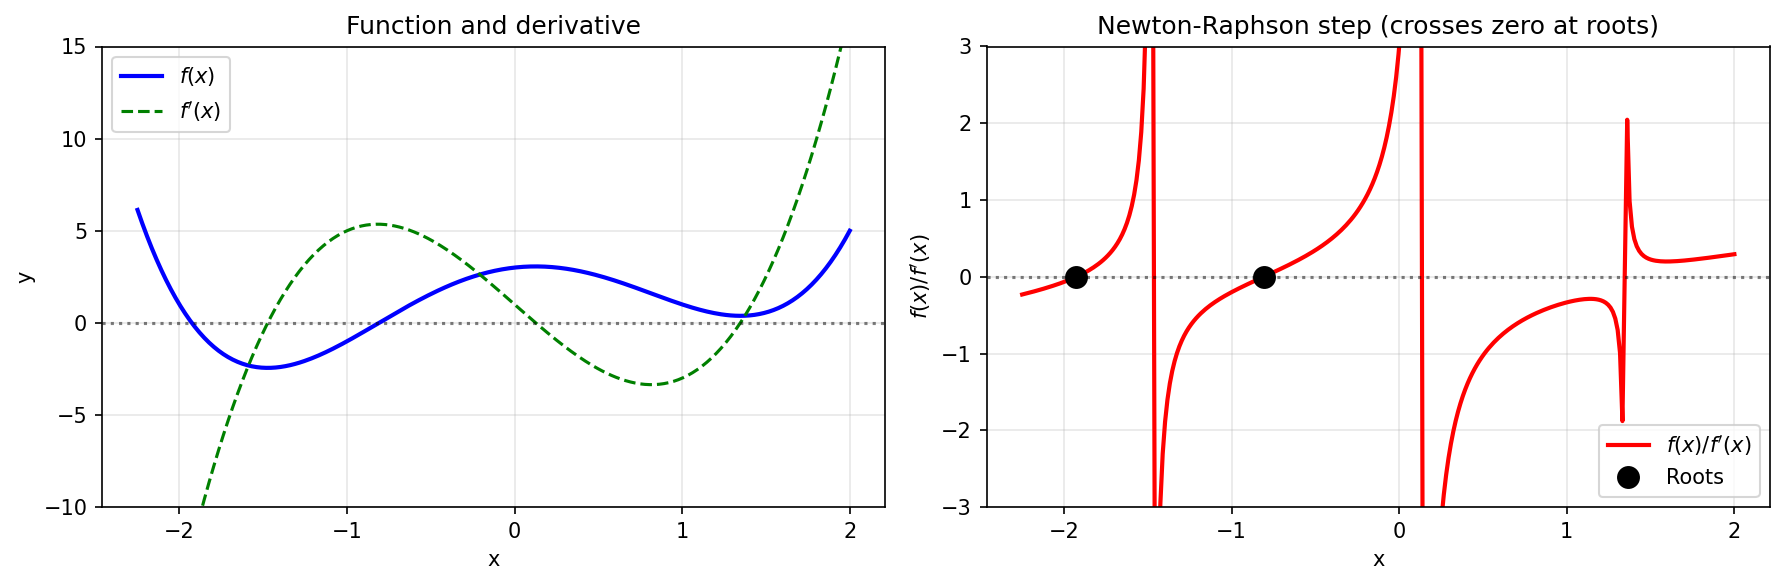

In [16]:
# Visualize f(x)/f'(x) - it crosses zero at the roots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: original function
axes[0].plot(x, y, 'b-', lw=2, label="$f(x)$")
axes[0].plot(x, y_prime, 'g--', lw=1.5, label="$f'(x)$")
axes[0].axhline(0, color='k', ls=':', alpha=0.5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].set_title('Function and derivative')
axes[0].set_ylim(-10, 15)
axes[0].grid(True, alpha=0.3)

# Right: Newton-Raphson step
axes[1].plot(x_filtered, nr_step, 'r-', lw=2, label="$f(x)/f'(x)$")
axes[1].axhline(0, color='k', ls=':', alpha=0.5)
axes[1].plot([-1.926, -0.809], [0, 0], 'ko', ms=10, label='Roots')
axes[1].set_xlabel('x')
axes[1].set_ylabel("$f(x)/f'(x)$")
axes[1].legend()
axes[1].set_title('Newton-Raphson step (crosses zero at roots)')
axes[1].set_ylim(-3, 3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Build GMM with x and f(x)/f'(x)
data_nr = np.array([x_filtered, nr_step]).T

gmm_nr, info = best_gmm(data_nr, verbose=True)
print(f"\nBest model: {info['best_k']} components")

k=1: BIC=2381.1 *
k=2: BIC=1937.4 *
k=3: BIC=1870.3 *
k=4: BIC=1634.5 *
k=5: BIC=1575.1 *
k=6: BIC=1222.6 *
k=7: BIC=1033.1 *
k=8: BIC=1122.0
k=9: BIC=1090.5
k=10: BIC=1003.5 *
k=11: BIC=869.4 *
k=12: BIC=711.8 *
k=13: BIC=843.5
k=14: BIC=848.1
k=15: BIC=684.5 *
k=16: BIC=659.7 *
k=17: BIC=598.0 *
k=18: BIC=641.8
k=19: BIC=554.3 *
k=20: BIC=529.8 *
k=21: BIC=564.6
k=22: BIC=491.0 *
k=23: BIC=441.0 *
k=24: BIC=479.4
k=25: BIC=425.8 *
k=26: BIC=438.4
k=27: BIC=440.9
k=28: BIC=382.7 *
k=29: BIC=387.7

Best model: 28 components


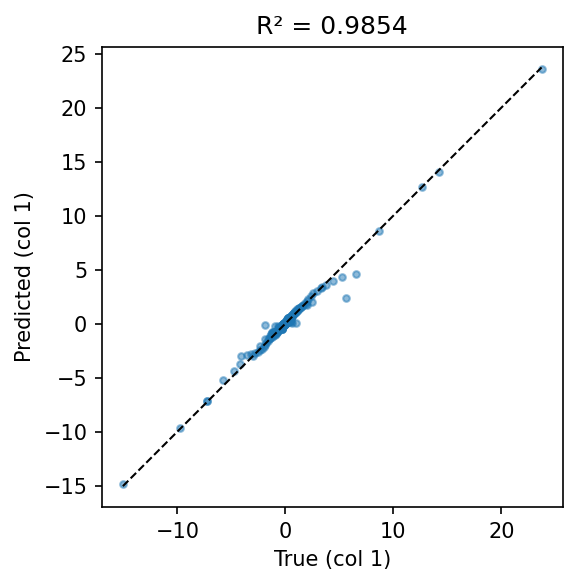


R² = 0.9854


In [18]:
# Validate the model
metrics = validate_gmm(gmm_nr, data_nr, input_cols=[0], output_cols=[1])
print(f"\nR² = {metrics['col_1']['R2']:.4f}")

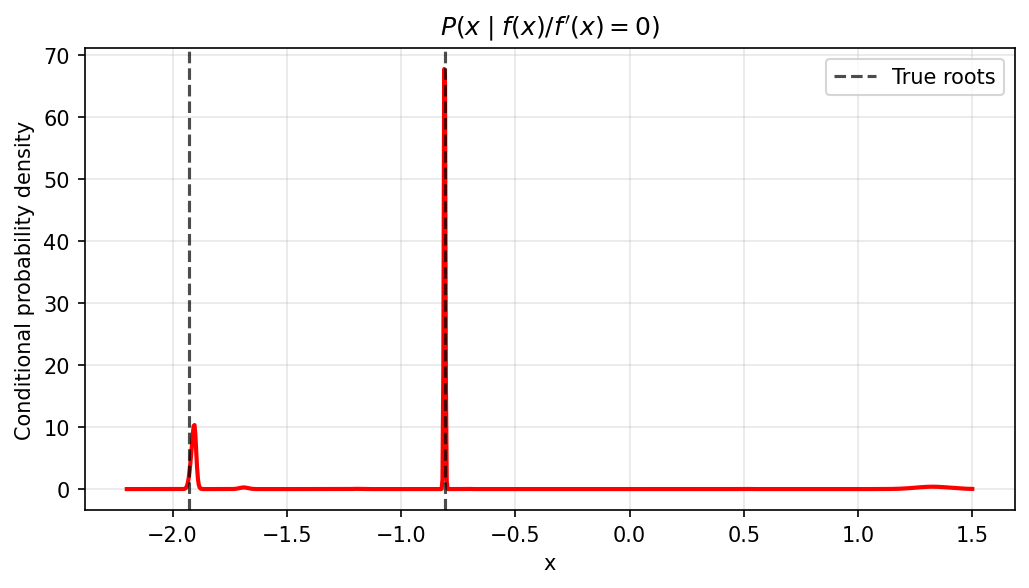

In [19]:
# Find roots by conditioning on f(x)/f'(x) = 0
c_nr = gmm_nr.condition([1], [[0.0]])

# Visualize conditional probability density
_x = np.linspace(-2.2, 1.5, 1000)[:, None]

plt.figure(figsize=(8, 4))
plt.plot(_x, c_nr.to_probability_density(_x), 'r-', lw=2)
plt.axvline(-1.926, color='k', ls='--', alpha=0.7, label='True roots')
plt.axvline(-0.809, color='k', ls='--', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Conditional probability density')
plt.title("$P(x \\mid f(x)/f'(x) = 0)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# Sample to find roots
print("Roots found by conditioning on f(x)/f'(x) = 0:")
samples_nr = c_nr.sample(1000)
cluster_stats(samples_nr)

print("\nComparison with true roots: -1.926, -0.809")

Roots found by conditioning on f(x)/f'(x) = 0:
 -1:   0.4915 +/- 0.0130 (n=2)
  0:  -0.8097 +/- 0.0054 (n=624)
  1:   1.3164 +/- 0.0666 (n=87)
  2:  -1.8959 +/- 0.0486 (n=287)

Comparison with true roots: -1.926, -0.809


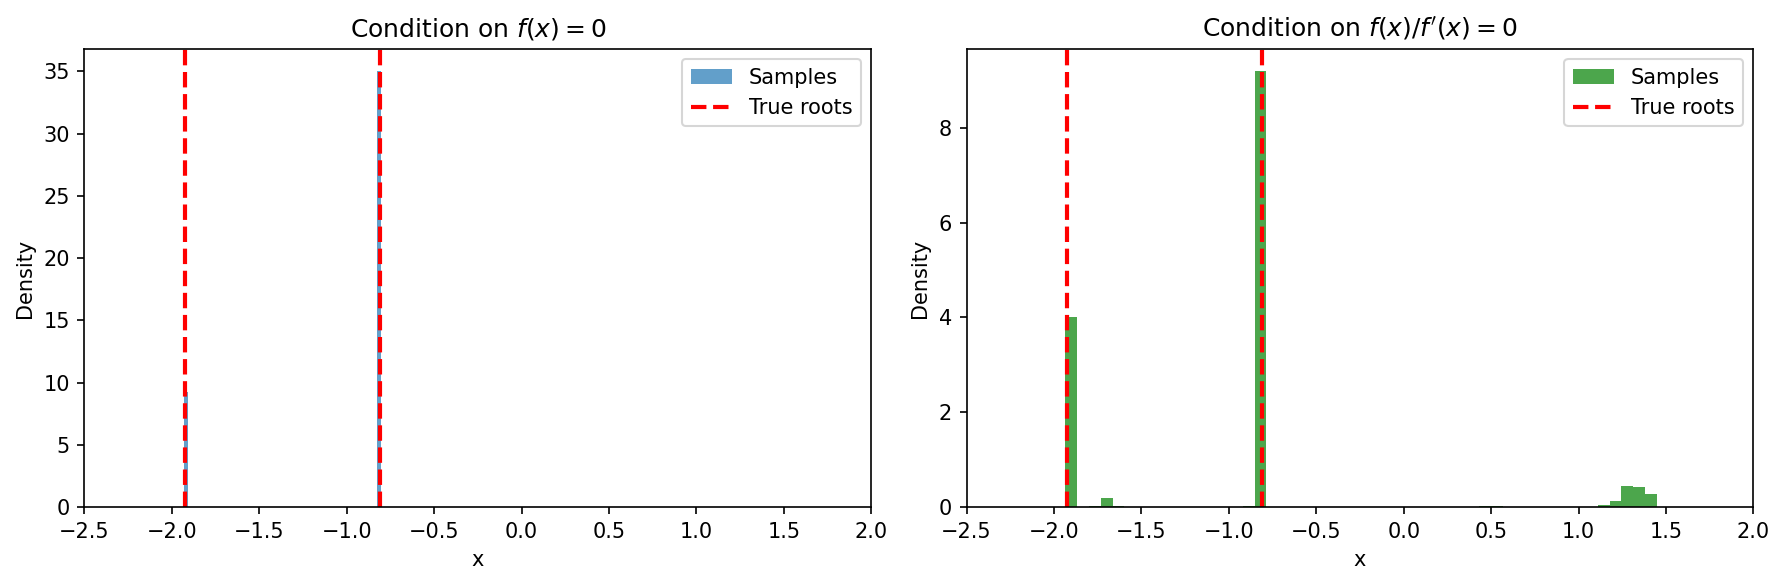

Both methods find the same roots, but the Newton-Raphson approach
naturally excludes regions near stationary points (where f'(x) ≈ 0).


In [21]:
# Compare: conditioning on f(x)=0 vs f(x)/f'(x)=0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Method 1: Condition on f(x) = 0 (from earlier)
data_fx = np.array([x, y]).T
gmm_fx, _ = best_gmm(data_fx, verbose=False)
c_fx = gmm_fx.condition([1], [[0.0]])
samples_fx = c_fx.sample(1000)

axes[0].hist(samples_fx, bins=50, alpha=0.7, density=True, label='Samples')
axes[0].axvline(-1.926, color='r', ls='--', lw=2, label='True roots')
axes[0].axvline(-0.809, color='r', ls='--', lw=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Density')
axes[0].set_title('Condition on $f(x) = 0$')
axes[0].legend()
axes[0].set_xlim(-2.5, 2)

# Method 2: Condition on f(x)/f'(x) = 0
axes[1].hist(samples_nr, bins=50, alpha=0.7, density=True, color='green', label='Samples')
axes[1].axvline(-1.926, color='r', ls='--', lw=2, label='True roots')
axes[1].axvline(-0.809, color='r', ls='--', lw=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Density')
axes[1].set_title("Condition on $f(x)/f'(x) = 0$")
axes[1].legend()
axes[1].set_xlim(-2.5, 2)

plt.tight_layout()
plt.show()

print("Both methods find the same roots, but the Newton-Raphson approach")
print("naturally excludes regions near stationary points (where f'(x) ≈ 0).")

<a id='imaginary-roots'></a>
### 2.2 Finding Imaginary Roots

To find imaginary roots, we sample a complex number input space by treating real and imaginary parts as separate dimensions.

Consider $x^3 - x^2 + x - 1 = 0$ which has roots at $x=1, \pm i$.

In [22]:
# Analytical roots
r = np.roots([1, -1, 1, -1])
print("Roots:")
print(r)
print("\nIn (real, imag) form:")
print(np.array([r.real, r.imag]).T)

Roots:
[ 1.00000000e+00+0.j -4.23416596e-16+1.j -4.23416596e-16-1.j]

In (real, imag) form:
[[ 1.00000000e+00  0.00000000e+00]
 [-4.23416596e-16  1.00000000e+00]
 [-4.23416596e-16 -1.00000000e+00]]


In [23]:
# Sample complex input space
# inputs[:, 0] = real part, inputs[:, 1] = imaginary part
bounds = [[-2, 2], [-2, 2]]
inputs = generate_samples(bounds, n_samples=200000, method='uniform', seed=42)

# Construct complex numbers and evaluate function
I = inputs[:, 0] + 1j * inputs[:, 1]
O = I**3 - I**2 + I - 1
outputs = np.array([O.real, O.imag]).T

print(f"Generated {len(inputs)} samples")

Generated 200000 samples


In [24]:
# Filter to samples near the target output [0, 0]
d = 0.2  # radius threshold
ind = np.sum(outputs**2, axis=1) < d**2
print(f"Samples near zero: {np.sum(ind)}")

data = np.hstack([inputs, outputs])[ind]
print(f"Data shape: {data.shape}")

Samples near zero: 815
Data shape: (815, 4)


Best model: 16 components


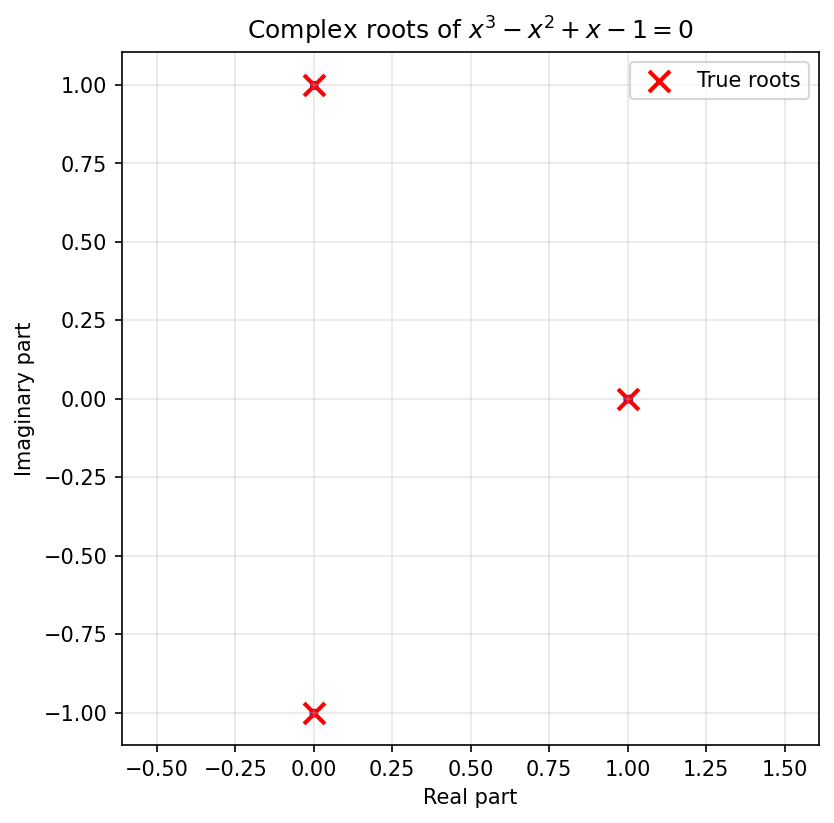

In [25]:
# Fit GMM and find roots
gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

# Condition on output = [0, 0] (real and imaginary parts both zero)
c = gmm.condition([2, 3], [[0.0, 0.0]])

# Sample and plot
results = c.sample(1000)

plt.figure(figsize=(6, 6))
plt.scatter(results[:, 0], results[:, 1], c='blue', s=5, alpha=0.3)
plt.scatter([1, 0, 0], [0, 1, -1], c='red', s=100, marker='x', 
            linewidths=2, label='True roots')
plt.xlabel('Real part')
plt.ylabel('Imaginary part')
plt.title('Complex roots of $x^3 - x^2 + x - 1 = 0$')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

---
<a id='optimization'></a>
## 3. Optimization with Generative Models

To find minima/maxima, we include derivatives in our data and condition on them being zero.

In [26]:
# Using the same polynomial: y = x^4 - 4x^2 + x + 3
# Derivative: y' = 4x^3 - 8x + 1

x = np.linspace(-2.25, 2, 200)
y = x**4 - 4*x**2 + x + 3
y_prime = 4*x**3 - 8*x + 1

# Find stationary points analytically
stationary_pts = np.roots([4, 0, -8, 1])
print("Stationary points (where y'=0):")
print(stationary_pts)

Stationary points (where y'=0):
[-1.4729976   1.34699741  0.12600019]


In [27]:
# Build GMM with x, y, and y'
data = np.array([x, y, y_prime]).T

gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 13 components


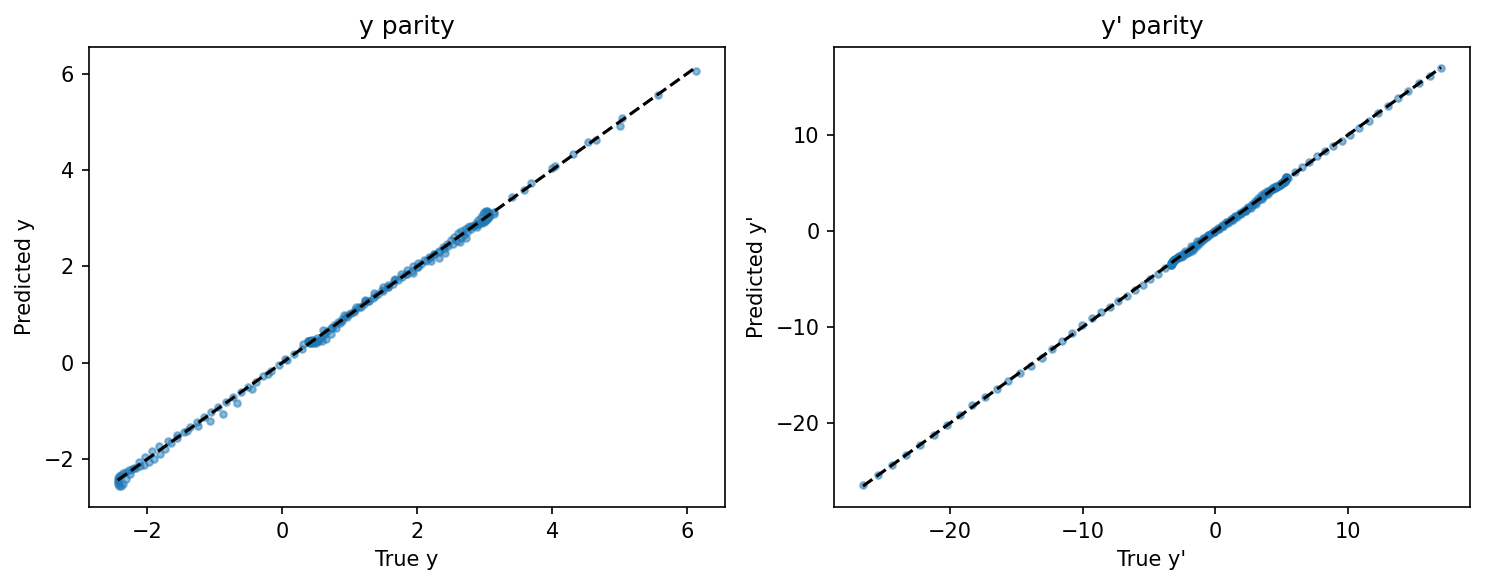

In [28]:
# Validate: condition on x, predict y and y'
pred = gmm.predict([0], data[:, 0:1])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(data[:, 1], pred[:, 0], alpha=0.5, s=10)
axes[0].plot([data[:, 1].min(), data[:, 1].max()], 
             [data[:, 1].min(), data[:, 1].max()], 'k--')
axes[0].set_xlabel('True y')
axes[0].set_ylabel('Predicted y')
axes[0].set_title('y parity')

axes[1].scatter(data[:, 2], pred[:, 1], alpha=0.5, s=10)
axes[1].plot([data[:, 2].min(), data[:, 2].max()], 
             [data[:, 2].min(), data[:, 2].max()], 'k--')
axes[1].set_xlabel("True y'")
axes[1].set_ylabel("Predicted y'")
axes[1].set_title("y' parity")

plt.tight_layout()
plt.show()

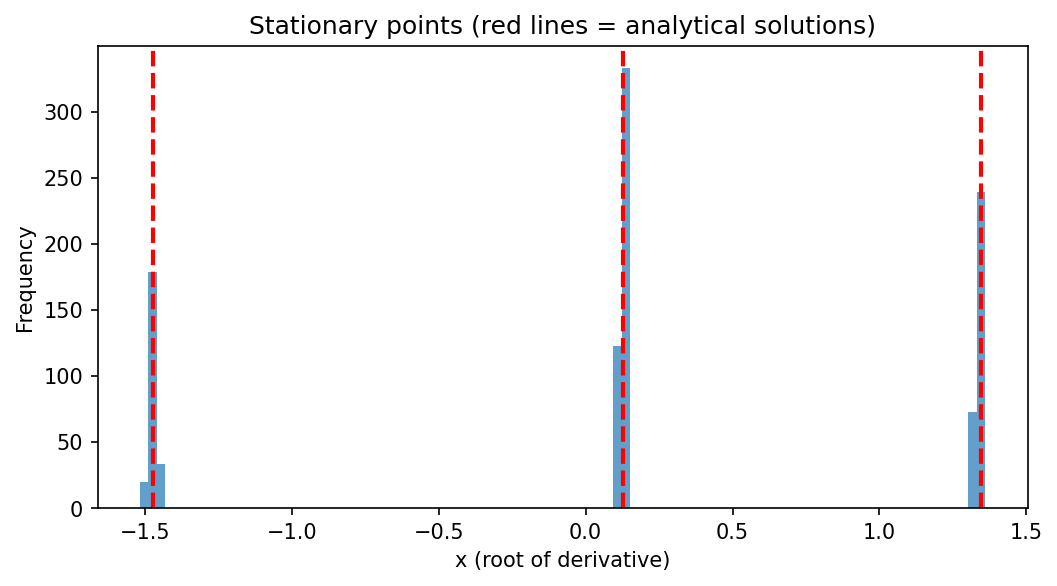

In [29]:
# Find stationary points by conditioning on y'=0
c = gmm.condition([2], [[0.0]])

results = c.sample(1000)

plt.figure(figsize=(8, 4))
plt.hist(results[:, 0], bins=100, alpha=0.7)
plt.xlabel('x (root of derivative)')
plt.ylabel('Frequency')

for r in np.roots([4, 0, -8, 1]):
    plt.axvline(r, c='r', ls='--', lw=2)

plt.title("Stationary points (red lines = analytical solutions)")
plt.show()

In [30]:
# Distinguish minima from maxima using second derivative
# y'' = 12x^2 - 8
# Use sign: +1 if y'' > 0 (minimum), -1 if y'' < 0 (maximum)

y_double_prime_sign = np.where((12 * x**2 - 8) > 0, 1, -1).astype(int)

data = np.array([x, y, y_prime, y_double_prime_sign]).T

gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 10 components


Maximum (y'=0, y''<0):
  0:   0.1268 +/- 0.0149 (n=100)


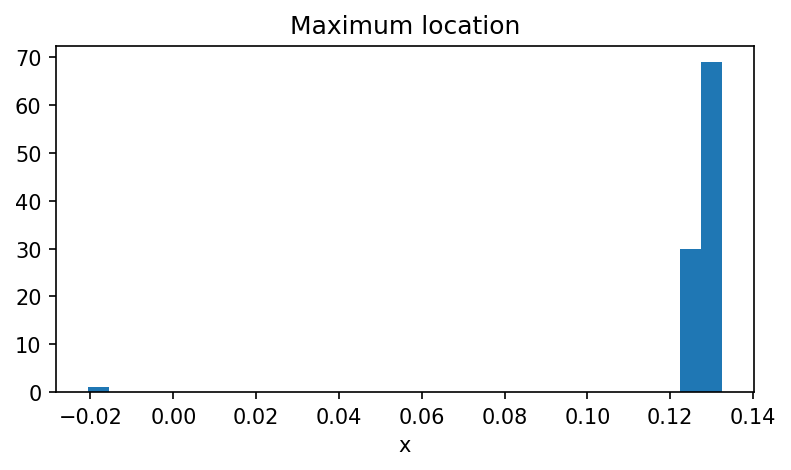

In [31]:
# Find maximum: condition on y'=0 AND y''<0 (sign=-1)
c = gmm.condition([2, 3], [[0.0, -1]])

results = c.sample(100)
print("Maximum (y'=0, y''<0):")
cluster_stats(results[:, 0])

plt.figure(figsize=(6, 3))
plt.hist(results[:, 0], bins=30)
plt.xlabel('x')
plt.title('Maximum location')
plt.show()

Minima (y'=0, y''>0):
  0:  -1.4578 +/- 0.0135 (n=60)
  1:   1.3423 +/- 0.0226 (n=40)


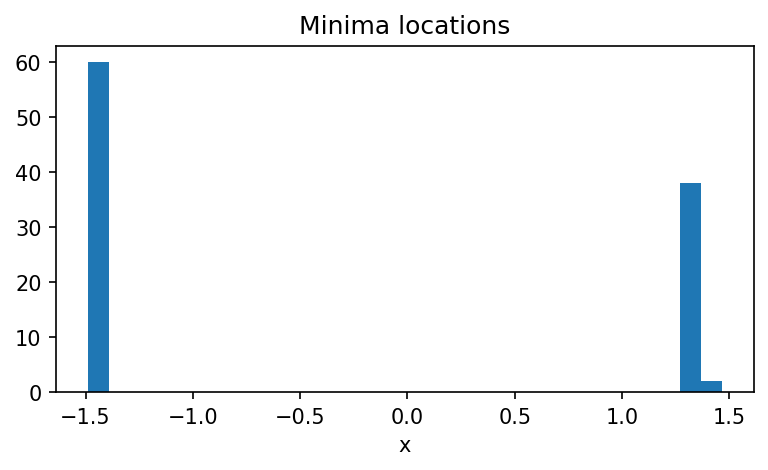

In [32]:
# Find minima: condition on y'=0 AND y''>0 (sign=+1)
c = gmm.condition([2, 3], [[0.0, 1]])

results = c.sample(100)
print("Minima (y'=0, y''>0):")
cluster_stats(results[:, 0])

plt.figure(figsize=(6, 3))
plt.hist(results[:, 0], bins=30)
plt.xlabel('x')
plt.title('Minima locations')
plt.show()

---
<a id='constrained'></a>
## 4. Constrained Optimization

<a id='equality'></a>
### 4.1 Equality Constraints

For equality constraints, we use a Lagrangian approach and condition on all Lagrangian derivatives being zero.

**Problem:** Minimize $x^2 + y^2 + z^2$ subject to $2x - y + z = 3$

In [33]:
# First, solve with scipy for comparison
from scipy.optimize import minimize

def objective(X):
    x, y, z = X
    return x**2 + y**2 + z**2

def eq_constraint(X):
    x, y, z = X
    return 2 * x - y + z - 3

sol = minimize(objective, [1, -0.5, 0.5], 
               constraints={'type': 'eq', 'fun': eq_constraint})

print("Scipy solution:")
print(f"  x = {sol.x}")
print(f"  f(x) = {sol.fun}")

Scipy solution:
  x = [ 1.  -0.5  0.5]
  f(x) = 1.5


In [34]:
# Define Lagrangian and use JAX for derivatives
from jax import jacobian, vmap

def f(X):
    x, y, z = X
    return x**2 + y**2 + z**2

def g(X):
    x, y, z = X
    return 2 * x - y + z - 3

def L(Y):
    """Lagrangian: L = f(x) + lambda * g(x)"""
    X, _lambda = Y[0:3], Y[3]
    return f(X) + _lambda * g(X)

In [35]:
# Generate samples of [x, y, z, lambda] and compute Lagrangian derivatives
bounds = [[-2, 2], [-2, 1], [-1, 1], [0, 1]]
Y = generate_samples(bounds, n_samples=128, seed=42)

# Compute Jacobian of Lagrangian for each sample
dL = vmap(jacobian(L))(Y)

# Data: [x, y, z, lambda, dL/dx, dL/dy, dL/dz, dL/dlambda]
data = np.hstack([Y, dL])
print(f"Data shape: {data.shape}")
print(f"Columns: [x, y, z, λ, ∂L/∂x, ∂L/∂y, ∂L/∂z, ∂L/∂λ]")

Data shape: (128, 8)
Columns: [x, y, z, λ, ∂L/∂x, ∂L/∂y, ∂L/∂z, ∂L/∂λ]


In [36]:
# Build GMM
gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 1 components


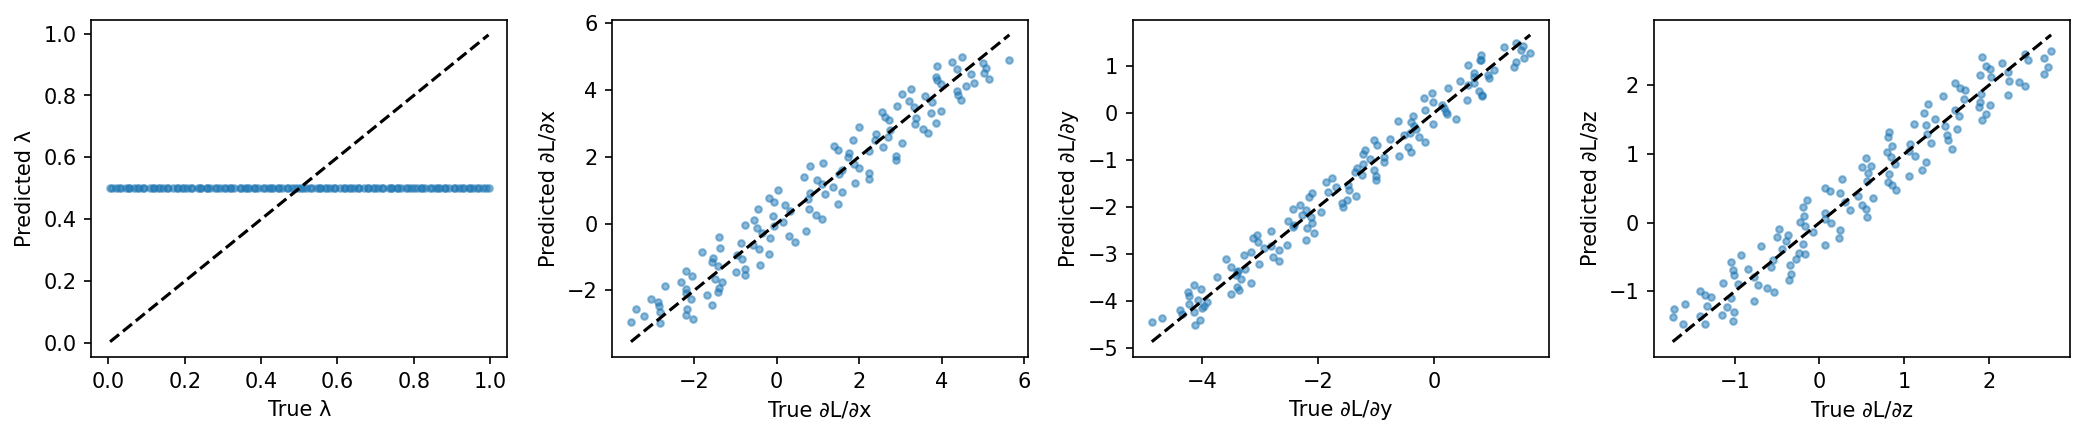

In [37]:
# Validate the model
pred = gmm.predict([0, 1, 2], data[:, 0:3])  # condition on x,y,z

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
labels = ['λ', '∂L/∂x', '∂L/∂y', '∂L/∂z']

for i, (ax, label) in enumerate(zip(axes, labels)):
    true = data[:, 3+i]
    predicted = pred[:, i]
    ax.scatter(true, predicted, alpha=0.5, s=10)
    lims = [min(true.min(), predicted.min()), max(true.max(), predicted.max())]
    ax.plot(lims, lims, 'k--')
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')

plt.tight_layout()
plt.show()

In [38]:
# Solve: condition on all Lagrangian derivatives = 0
P = gmm.predict([4, 5, 6, 7], np.array([[0.0, 0.0, 0.0, 0.0]]))

x_opt, y_opt, z_opt = P[0, 0:3]
lambda_opt = P[0, 3]

print("Generative solution:")
print(f"  x = {x_opt:.6f}")
print(f"  y = {y_opt:.6f}")
print(f"  z = {z_opt:.6f}")
print(f"  λ = {lambda_opt:.6f}")
print(f"\nComparison with scipy: x = [1.0, -0.5, 0.5]")

Generative solution:
  x = 0.999998
  y = -0.499999
  z = 0.499999
  λ = -0.999995

Comparison with scipy: x = [1.0, -0.5, 0.5]


<a id='inequality'></a>
### 4.2 Inequality Constraints (Barrier Method)

For inequality constraints, we use the barrier method.

**Problem:** Minimize $(x-2)^2 + (y-1)^2$ subject to $x + y \geq 1$

In [39]:
# Scipy solution
from scipy.optimize import minimize

def f(X):
    x, y = X
    return (x - 2)**2 + (y - 1)**2

def c1(X):
    x, y = X
    return x + y - 1  # >= 0

sol = minimize(f, [1, 1], constraints={'type': 'ineq', 'fun': c1})

print("Scipy solution:")
print(f"  x = {sol.x}")
print(f"  f(x) = {sol.fun}")

Scipy solution:
  x = [2.         0.99999999]
  f(x) = 5.551115123125783e-17


In [40]:
# Barrier method with JAX
import jax.numpy as jnp
from jax import jacobian, vmap

def barrier_objective(X, mu=1e-7):
    x, y = X
    obj = (x - 2)**2 + (y - 1)**2
    barrier = -mu * jnp.log(x + y - 1)
    return obj + barrier

# Generate samples in feasible region (x + y > 1)
bounds = [[0, 3], [0, 3]]
inputs = generate_samples(bounds, n_samples=512, method='uniform', seed=42)

# Filter to feasible points
feasible = inputs[:, 0] + inputs[:, 1] > 1.01  # small margin for log
inputs = inputs[feasible]

print(f"Feasible samples: {len(inputs)}")

Feasible samples: 469


In [41]:
# Compute gradients
outputs = vmap(jacobian(barrier_objective))(inputs)
data = np.hstack([inputs, outputs])

print(f"Data shape: {data.shape}")
print("Columns: [x, y, ∂f_barrier/∂x, ∂f_barrier/∂y]")

Data shape: (469, 4)
Columns: [x, y, ∂f_barrier/∂x, ∂f_barrier/∂y]


Best model: 2 components


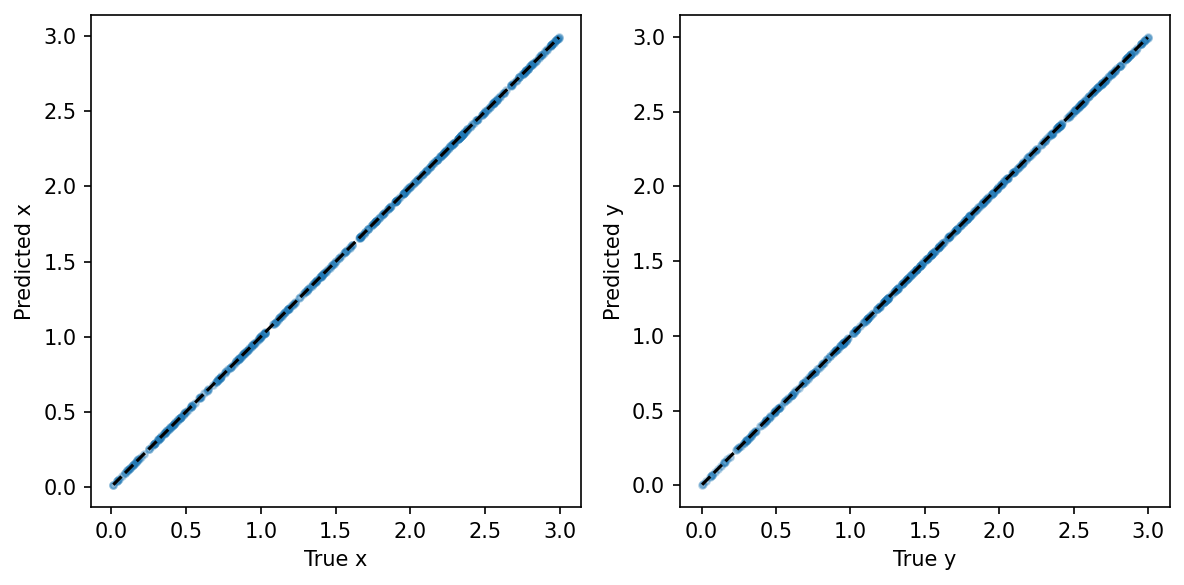

In [42]:
# Build and validate GMM
gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

# Validate
pred = gmm.predict([2, 3], data[:, 2:])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i, (ax, label) in enumerate(zip(axes, ['x', 'y'])):
    ax.scatter(data[:, i], pred[:, i], alpha=0.3, s=10)
    lims = [data[:, i].min(), data[:, i].max()]
    ax.plot(lims, lims, 'k--')
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')

plt.tight_layout()
plt.show()

In [43]:
# Solve: condition on gradient = 0
P = gmm.predict([2, 3], np.array([[0.0, 0.0]]))

print("Generative solution:")
print(f"  x = {P[0, 0]:.6f}")
print(f"  y = {P[0, 1]:.6f}")
print(f"\nExpected: x = 2.0, y = 1.0")

Generative solution:
  x = 2.000000
  y = 1.000000

Expected: x = 2.0, y = 1.0


---
<a id='parameter-estimation'></a>
## 5. Parameter Estimation

Parameter estimation as an inverse problem: given observations, find the parameters.

**Example:** Series reaction A → B → C in a plug flow reactor. Given exit molar flows, estimate rate constants $k_1$ and $k_2$.

In [44]:
from scipy.integrate import solve_ivp

# Reactor parameters
nu = 1   # volumetric flow rate
Vf = 2   # reactor volume
F0 = [1, 0]  # inlet molar flows [Fa0, Fb0]

def ode(V, F, k1, k2):
    """ODE system for series reaction A -> B -> C"""
    Fa, Fb = F
    dFadV = -k1 * Fa / nu
    dFbdV = k1 * Fa / nu - k2 * Fb / nu
    return dFadV, dFbdV

In [45]:
# Generate data: sample rate constants and compute exit flows
bounds = [[0.1, 3], [0.1, 3]]
K = generate_samples(bounds, n_samples=128, seed=42)

data = []
for k1, k2 in K:
    sol = solve_ivp(ode, t_span=(0, Vf), y0=F0, args=(k1, k2))
    Fa, Fb = sol.y[:, -1]
    data.append([k1, k2, Fa, Fb])

data = np.array(data)
print(f"Data shape: {data.shape}")
print("Columns: [k1, k2, Fa_exit, Fb_exit]")

Data shape: (128, 4)
Columns: [k1, k2, Fa_exit, Fb_exit]


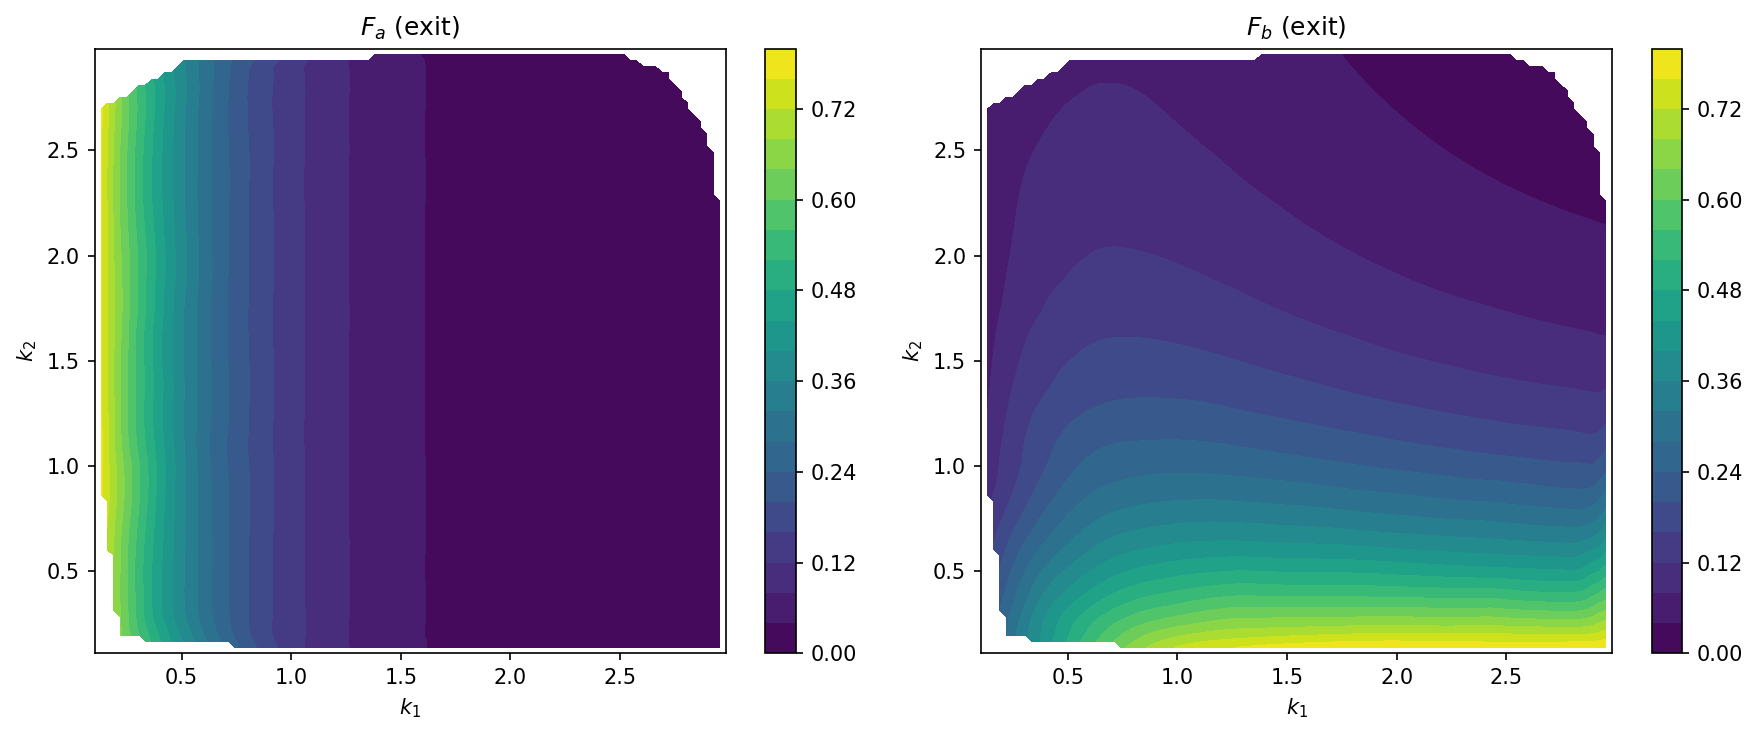

In [46]:
# Visualize the data
from scipy.interpolate import griddata

xi = np.linspace(data[:, 0].min(), data[:, 0].max(), 100)
yi = np.linspace(data[:, 1].min(), data[:, 1].max(), 100)
X, Y = np.meshgrid(xi, yi)
Z1 = griddata((data[:, 0], data[:, 1]), data[:, 2], (X, Y), method='cubic')
Z2 = griddata((data[:, 0], data[:, 1]), data[:, 3], (X, Y), method='cubic')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

c1 = axes[0].contourf(X, Y, Z1, levels=20)
axes[0].set_xlabel('$k_1$')
axes[0].set_ylabel('$k_2$')
axes[0].set_title('$F_a$ (exit)')
plt.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(X, Y, Z2, levels=20)
axes[1].set_xlabel('$k_1$')
axes[1].set_ylabel('$k_2$')
axes[1].set_title('$F_b$ (exit)')
plt.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.show()

Best model: 6 components


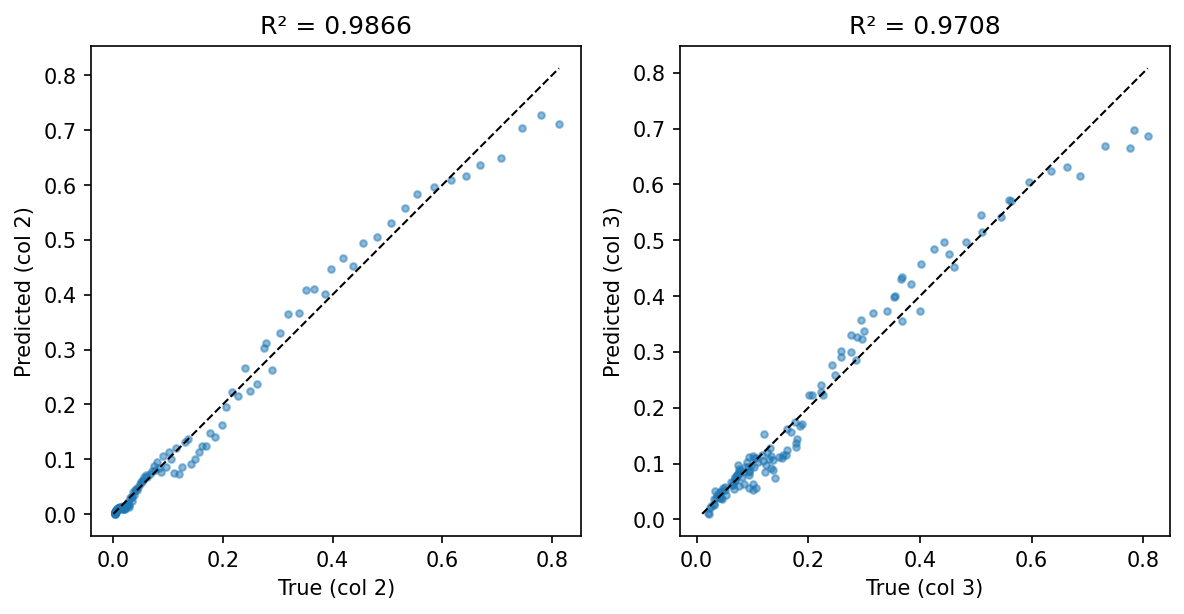

In [47]:
# Build GMM
gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

# Validate
metrics = validate_gmm(gmm, data, input_cols=[0, 1], output_cols=[2, 3])

In [48]:
# Parameter estimation for two scenarios:
# 1. Low Fa, low Fb (both reactions fast)
# 2. Low Fa, high Fb (reaction 1 fast, reaction 2 slow)

observations = np.array([[0.02, 0.05],   # low Fa, low Fb
                         [0.02, 0.65]])  # low Fa, high Fb

P = gmm.predict([2, 3], observations)

print("Parameter estimates:")
print(f"\nScenario 1 (low Fa, low Fb - both reactions fast):")
print(f"  k1 = {P[0, 0]:.4f}, k2 = {P[0, 1]:.4f}")

print(f"\nScenario 2 (low Fa, high Fb - reaction 2 slow):")
print(f"  k1 = {P[1, 0]:.4f}, k2 = {P[1, 1]:.4f}")

Parameter estimates:

Scenario 1 (low Fa, low Fb - both reactions fast):
  k1 = 1.8211, k2 = 2.4735

Scenario 2 (low Fa, high Fb - reaction 2 slow):
  k1 = 1.8989, k2 = 0.2813


In [49]:
# Verify the estimates
for i, (obs, params) in enumerate(zip(observations, P)):
    k1, k2 = params
    Fa_exit, Fb_exit = solve_ivp(ode, t_span=(0, Vf), y0=F0, 
                                  args=(k1, k2)).y[:, -1]
    print(f"Scenario {i+1}:")
    print(f"  Estimated k = [{k1:.3f}, {k2:.3f}]")
    print(f"  Target:  Fa={obs[0]:.3f}, Fb={obs[1]:.3f}")
    print(f"  Actual:  Fa={Fa_exit:.3f}, Fb={Fb_exit:.3f}")
    print()

Scenario 1:
  Estimated k = [1.821, 2.473]
  Target:  Fa=0.020, Fb=0.050
  Actual:  Fa=0.026, Fb=0.053

Scenario 2:
  Estimated k = [1.899, 0.281]
  Target:  Fa=0.020, Fb=0.650
  Actual:  Fa=0.022, Fb=0.642



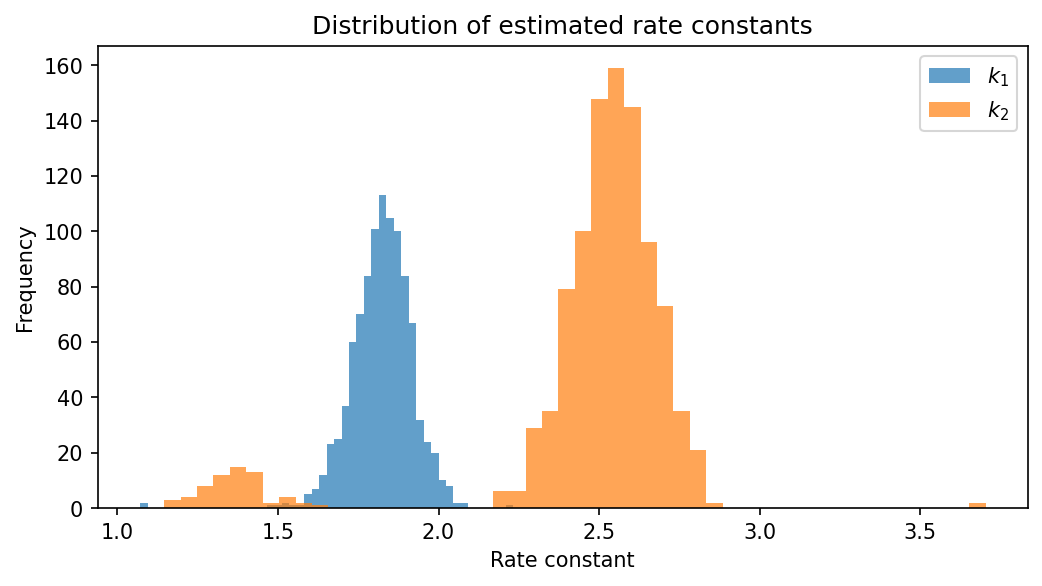

k1 = 1.823 ± 0.095
k2 = 2.471 ± 0.317


In [50]:
# Uncertainty estimation via sampling
c = gmm.condition([2, 3], np.array([[0.02, 0.05]]))
ks = c.sample(1000)

plt.figure(figsize=(8, 4))
plt.hist(ks[:, 0], bins=50, alpha=0.7, label='$k_1$')
plt.hist(ks[:, 1], bins=50, alpha=0.7, label='$k_2$')
plt.xlabel('Rate constant')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of estimated rate constants')
plt.show()

m, s = np.mean(ks, axis=0), np.std(ks, axis=0)
print(f"k1 = {m[0]:.3f} ± {s[0]:.3f}")
print(f"k2 = {m[1]:.3f} ± {s[1]:.3f}")

### 5.1 Caveats: Extrapolation

The generative approach fails for observations outside the training data range.

In [51]:
# Extrapolation examples (unphysical observations)
bad_observations = np.array([[0.02, -0.5],   # negative concentration
                             [0.02, 2.0]])   # Fb > F0 (impossible)

P_bad = gmm.predict([2, 3], bad_observations)

print("Extrapolation results (unreliable!):")
print(f"\nNegative Fb observation:")
print(f"  Estimated k = [{P_bad[0, 0]:.4f}, {P_bad[0, 1]:.4f}]")

print(f"\nFb > inlet flow observation:")
print(f"  Estimated k = [{P_bad[1, 0]:.4f}, {P_bad[1, 1]:.4f}]")
print("  Note: negative k2 is unphysical!")

Extrapolation results (unreliable!):

Negative Fb observation:
  Estimated k = [1.8317, 2.3442]

Fb > inlet flow observation:
  Estimated k = [2.0194, -2.1172]
  Note: negative k2 is unphysical!


---
<a id='mapping'></a>
## 6. Mapping Input and Output Spaces

Mapping a desired output region to the corresponding input region.

**Example:** CSTR with reactions A → B (2nd order) and A → C (1st order). Map desired concentrations (Ca, Cb) to design parameters (radius R, temperature RT).

In [52]:
# CSTR model
H = 1     # height
vo = 1    # volumetric flow rate
Cao = 1   # inlet concentration

# Sample input space (R, RT)
bounds = [[0.1, 3], [0.1, 15]]
X = generate_samples(bounds, n_samples=512, seed=42)

R, RT = X.T
V = np.pi * R**2 * H
k1 = np.exp(-3 / RT)
k2 = np.exp(-10 / RT)

# Solve quadratic for Ca
a = V * k1
b = vo + V * k2
c = -vo * Cao
Ca = (-b + np.sqrt(b**2 - 4 * a * c)) / (2 * a)

# Compute Cb
Cb = k1 * Ca**2 * V / vo

print(f"Generated {len(X)} samples")
print(f"Ca range: [{Ca.min():.3f}, {Ca.max():.3f}]")
print(f"Cb range: [{Cb.min():.3f}, {Cb.max():.3f}]")

Generated 512 samples
Ca range: [0.061, 1.000]
Cb range: [0.000, 0.620]


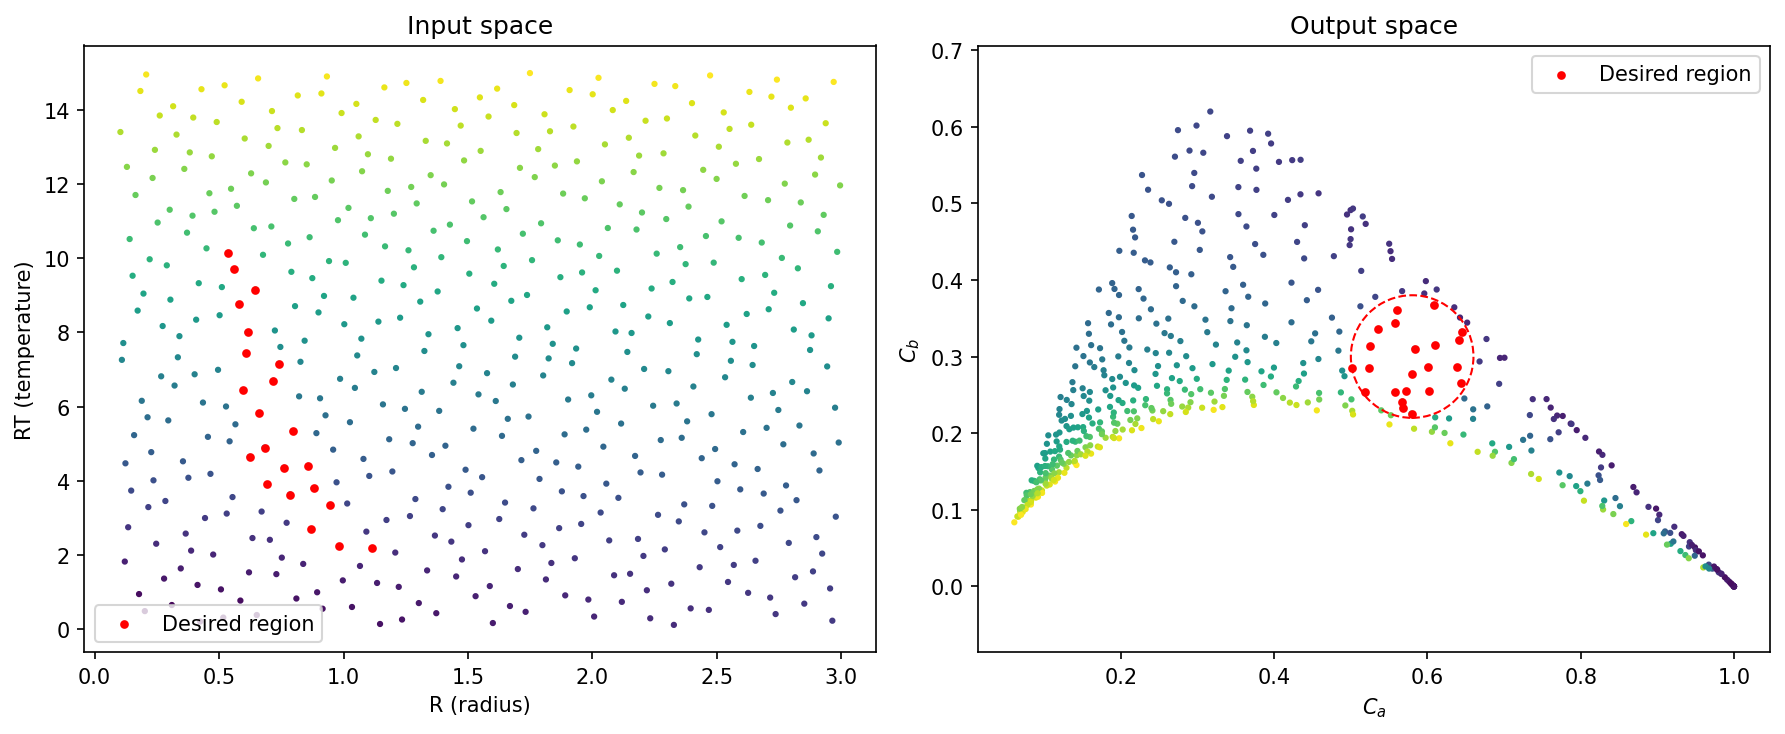

In [53]:
# Visualize input-output relationship
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Define desired output region
center = (0.58, 0.3)
radius = 0.08
dos = ((Ca - center[0])**2 + (Cb - center[1])**2) <= radius**2

# Color by distance from origin
colors = np.sqrt(R**2 + RT**2)

axes[0].scatter(R, RT, s=4, c=colors, cmap='viridis')
axes[0].scatter(R[dos], RT[dos], c='red', s=10, label='Desired region')
axes[0].set_xlabel('R (radius)')
axes[0].set_ylabel('RT (temperature)')
axes[0].set_title('Input space')
axes[0].legend()

axes[1].scatter(Ca, Cb, s=4, c=colors, cmap='viridis')
axes[1].scatter(Ca[dos], Cb[dos], c='red', s=10, label='Desired region')
circle = plt.Circle(center, radius, fill=False, color='red', linestyle='--')
axes[1].add_patch(circle)
axes[1].set_xlabel('$C_a$')
axes[1].set_ylabel('$C_b$')
axes[1].set_title('Output space')
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

In [54]:
# Build GMM for mapping
data = np.array([R, RT, Ca, Cb]).T

gmm, info = best_gmm(data, verbose=False)
print(f"Best model: {info['best_k']} components")

Best model: 22 components


In [55]:
# Generate samples in desired output region and map to input space
x1 = np.linspace(center[0] - radius, center[0] + radius, 100)
x2 = np.linspace(center[1] - radius, center[1] + radius, 100)
X1, X2 = np.meshgrid(x1, x2)
X1_flat = X1.flatten()
X2_flat = X2.flatten()

# Filter to points inside circle
ind = (X1_flat - center[0])**2 + (X2_flat - center[1])**2 <= radius**2

# Predict input space (R, RT) from output space (Ca, Cb)
pred = gmm.predict([2, 3], np.array([X1_flat[ind], X2_flat[ind]]).T)
P1, P2 = pred.T

print(f"Mapped {len(P1)} points from output to input space")

Mapped 7668 points from output to input space


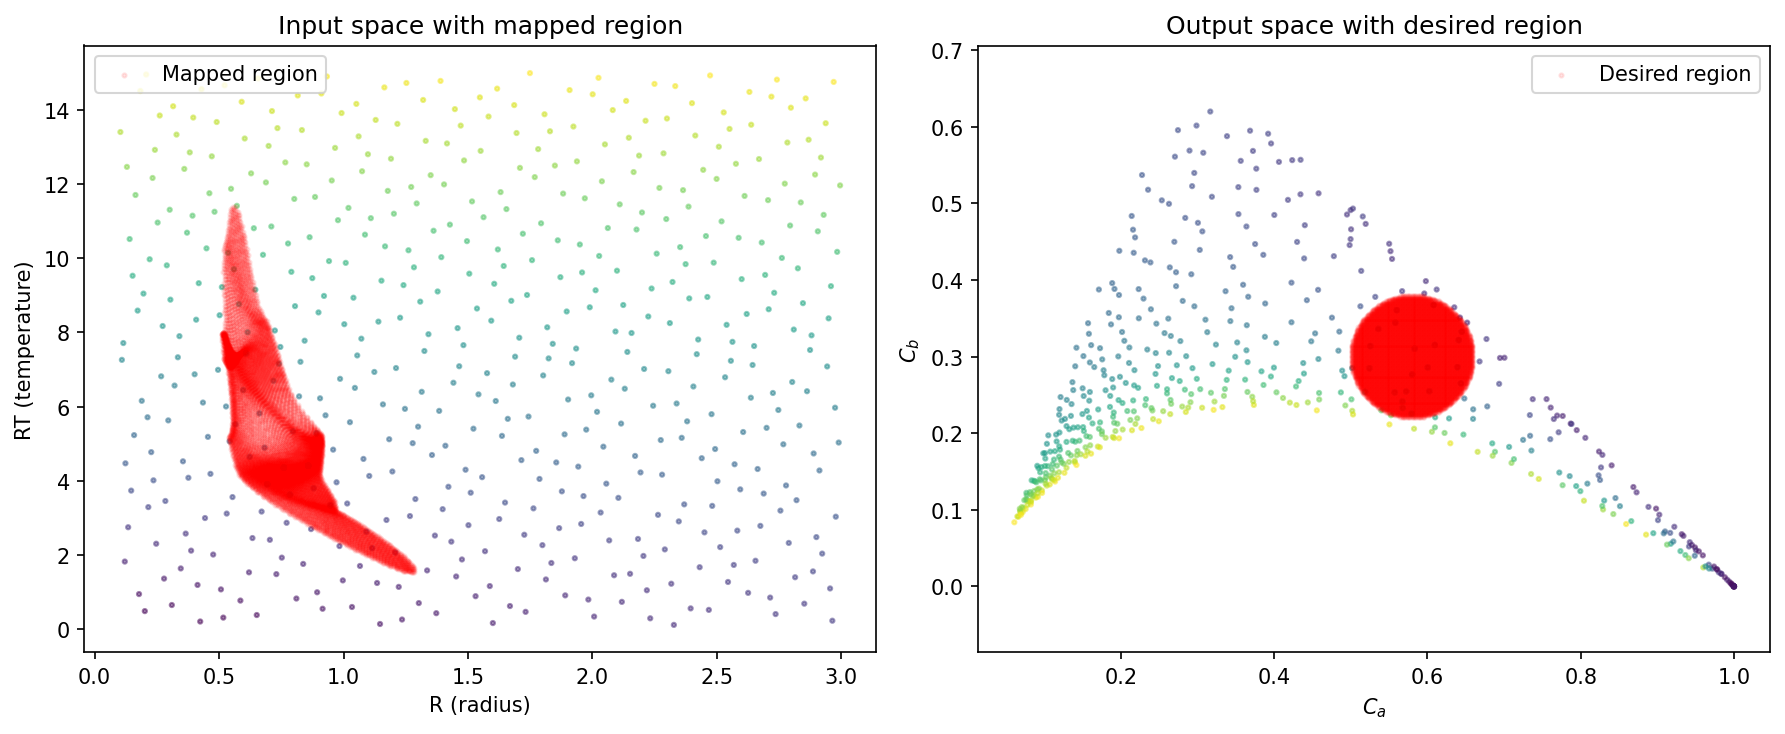

In [56]:
# Visualize the mapping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Input space
axes[0].scatter(R, RT, s=4, c=colors, cmap='viridis', alpha=0.5)
axes[0].scatter(P1, P2, s=4, c='red', alpha=0.1, label='Mapped region')
axes[0].set_xlabel('R (radius)')
axes[0].set_ylabel('RT (temperature)')
axes[0].set_title('Input space with mapped region')
axes[0].legend()

# Output space
axes[1].scatter(Ca, Cb, s=4, c=colors, cmap='viridis', alpha=0.5)
axes[1].scatter(X1_flat[ind], X2_flat[ind], c='red', s=4, alpha=0.1, 
                label='Desired region')
axes[1].set_xlabel('$C_a$')
axes[1].set_ylabel('$C_b$')
axes[1].set_title('Output space with desired region')
axes[1].axis('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated generative machine learning approaches to:

1. **Root finding** - Condition on output = target value
2. **Optimization** - Include derivatives, condition on derivative = 0
3. **Constrained optimization** - Use Lagrangian (equality) or barrier method (inequality)
4. **Parameter estimation** - Condition on observations to find parameters
5. **Space mapping** - Map between input and output spaces bidirectionally

Key advantages:
- Single unified approach across problem types
- No iterative solving required at inference time
- Naturally provides uncertainty estimates via sampling
- Works bidirectionally (forward and inverse)

Limitations:
- Requires sufficient data to learn the joint distribution
- Limited to in-distribution predictions (no extrapolation)
- Solution accuracy depends on GMM fit quality